In [44]:
import os
import logging
from typing import Dict, Tuple
from pathlib import Path

import numpy as np
import pandas as pd
from nixtla import NixtlaClient
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tqdm import tqdm
from dotenv import load_dotenv

logging.getLogger("nixtla").setLevel(logging.WARNING)
load_dotenv()

True

In [45]:
NIXTLA_API_KEY: str = os.getenv("NIXTLA_API_KEY")
DATA_PATH: Path = Path("commodity_features.csv")
DATE_COL: str = "date"
TARGET_COL: str = "CO1 Comdty"
TRAIN_RATIO: float = 0.90
FINETUNE_STEPS: int = 50
FINETUNE_DEPTH: int = 2
FINETUNE_LOSS: str = "mae"
MODEL_ID: str = "commodity_co1_model"
MODEL_NAME: str = "timegpt-1"  # "timegpt-1-long-horizon"
FORECAST_FREQUENCY: str = "D"  # "D", "W" " "M", "ME" #B= business days
FORECAST_HORIZON: int = 1
CONFIDENCE_LEVELS: list[int] = [80, 99]

nixtla_client = NixtlaClient(api_key=NIXTLA_API_KEY)

In [46]:
def load_and_prepare_data(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = df.rename(columns={DATE_COL: "ds", TARGET_COL: "y"})
    df["ds"] = pd.to_datetime(df["ds"], errors="coerce").dt.tz_localize(None)
    df["y"] = pd.to_numeric(df["y"], errors="coerce")

    df = df.resample(FORECAST_FREQUENCY, on="ds").last().reset_index()

    return (
        df[["ds", "y"]]
        .dropna(subset=["ds", "y"])
        .drop_duplicates(subset=["ds"])
        .sort_values("ds")
        .reset_index(drop=True)
    )


raw_data = load_and_prepare_data(DATA_PATH)
raw_data.head()

,ds,y
0,2003-04-11,24.75
1,2003-04-12,24.75
2,2003-04-13,24.75
3,2003-04-14,24.99
4,2003-04-15,25.20


In [47]:
def split_data(
    df: pd.DataFrame, train_ratio: float
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    n_total = len(df)
    n_train = int(n_total * train_ratio)

    train_df = df.iloc[:n_train].copy()
    test_df = df.iloc[n_train:].copy()

    return train_df, test_df


train_data, test_data = split_data(raw_data, TRAIN_RATIO)

assert train_data["ds"].max() < test_data["ds"].min()

print(f"Train shape: {train_data.shape}")
print(f"Test shape: {test_data.shape}")

Train shape: (7290, 2)
Test shape: (811, 2)


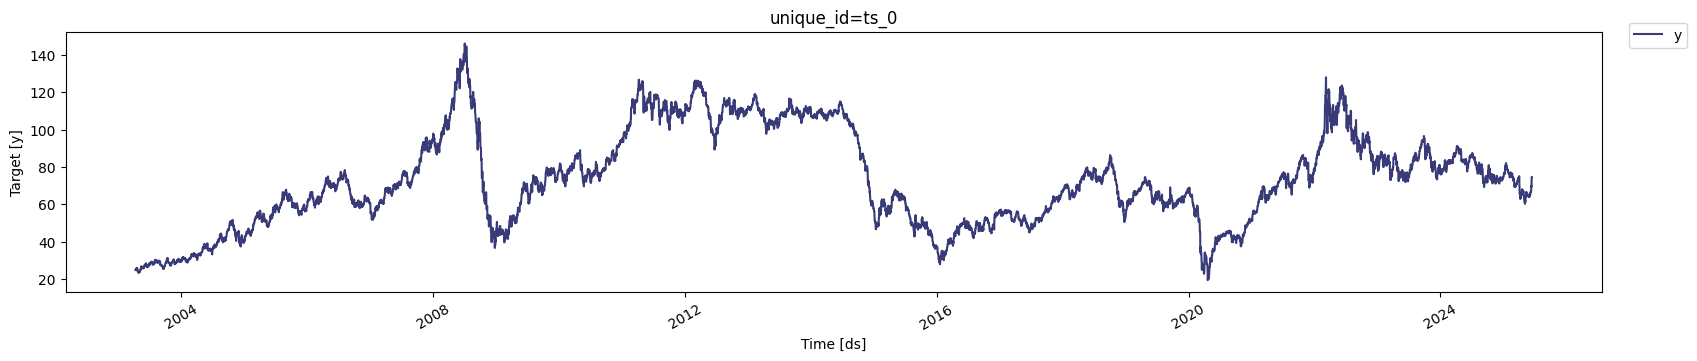

In [48]:
nixtla_client.plot(raw_data)

In [49]:
finetuned_model_id = nixtla_client.finetune(
    df=train_data,
    time_col="ds",
    target_col="y",
    freq=FORECAST_FREQUENCY,
    finetune_steps=FINETUNE_STEPS,
    finetune_depth=FINETUNE_DEPTH,
    finetune_loss=FINETUNE_LOSS,
    output_model_id=MODEL_ID,
    model=MODEL_NAME,
)

print(f"Model finetuned with {len(train_data)} {FORECAST_FREQUENCY} of training data")
print(f"Model ID: {finetuned_model_id}")

Model finetuned with 7290 D of training data
Model ID: commodity_co1_model


In [ ]:
def direct_forecast(
    client: NixtlaClient,
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    model_id: str,
    levels: list[int],
    **kwargs,
) -> Tuple[pd.DataFrame, Dict[str, float]]:

    forecast = client.forecast(
        df=train_df,
        h=len(test_df),
        time_col="ds",
        target_col="y",
        finetuned_model_id=model_id,
        level=levels,
        freq=FORECAST_FREQUENCY,
        model=MODEL_NAME,
    )

    results = test_df.merge(forecast, on="ds", how="left")

    return results


def expanding_window_forecast(
    client: NixtlaClient,
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    model_id: str,
    levels: list[int],
    forecast_horizon: int,
) -> pd.DataFrame:
    predictions = []
    current_train = train_df.copy()

    test_df_len = len(test_df)
    total_steps = (test_df_len + forecast_horizon - 1) // forecast_horizon

    for step in tqdm(range(total_steps), desc="Expanding Window Forecast"):
        forecast_start = step * forecast_horizon
        forecast_end = min(forecast_start + forecast_horizon, test_df_len)
        current_h = forecast_end - forecast_start

        if current_h <= 0:
            break

        forecast = client.forecast(
            df=current_train,
            h=current_h,
            time_col="ds",
            target_col="y",
            finetuned_model_id=model_id,
            level=levels,
            freq=FORECAST_FREQUENCY,
            model=MODEL_NAME,
        )

        for i in range(current_h):
            pred_idx = forecast_start + i
            if pred_idx < test_df_len:
                pred_data = {
                    "ds": test_df["ds"].iloc[pred_idx],
                    "y": test_df["y"].iloc[pred_idx],
                    "TimeGPT": forecast["TimeGPT"].iloc[i],
                    **{
                        f"TimeGPT-lo-{level}": forecast[f"TimeGPT-lo-{level}"].iloc[i]
                        for level in levels
                    },
                    **{
                        f"TimeGPT-hi-{level}": forecast[f"TimeGPT-hi-{level}"].iloc[i]
                        for level in levels
                    },
                }

                predictions.append(pred_data)

        if forecast_start < test_df_len:
            new_observations = test_df.iloc[:forecast_end][["ds", "y"]].copy()
            current_train = pd.concat(
                [current_train, new_observations], ignore_index=True
            )
            current_train = current_train.drop_duplicates(subset=["ds"]).sort_values(
                "ds"
            )

    return pd.DataFrame(predictions)


def evaluate_forecast(y_true: pd.Series, y_pred: pd.Series) -> Dict[str, float]:
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mask = y_true != 0
    mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask])
    r2 = r2_score(y_true, y_pred)

    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "MAPE": mape, "R2": r2}


# direct_forecast function can be used, keep parameters same
test_results = expanding_window_forecast(
    client=nixtla_client,
    train_df=train_data,
    test_df=test_data,
    model_id=finetuned_model_id,
    levels=CONFIDENCE_LEVELS,
    forecast_horizon=FORECAST_HORIZON,
)

test_metrics = evaluate_forecast(test_results["y"], test_results["TimeGPT"])

print(f"\nTest Metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

Expanding Window Forecast: 100%|██████████| 811/811 [16:10<00:00,  1.20s/it]


Test Metrics:
MAE: 0.9315
MSE: 1.7424
RMSE: 1.3200
MAPE: 0.0120
R2: 0.9647


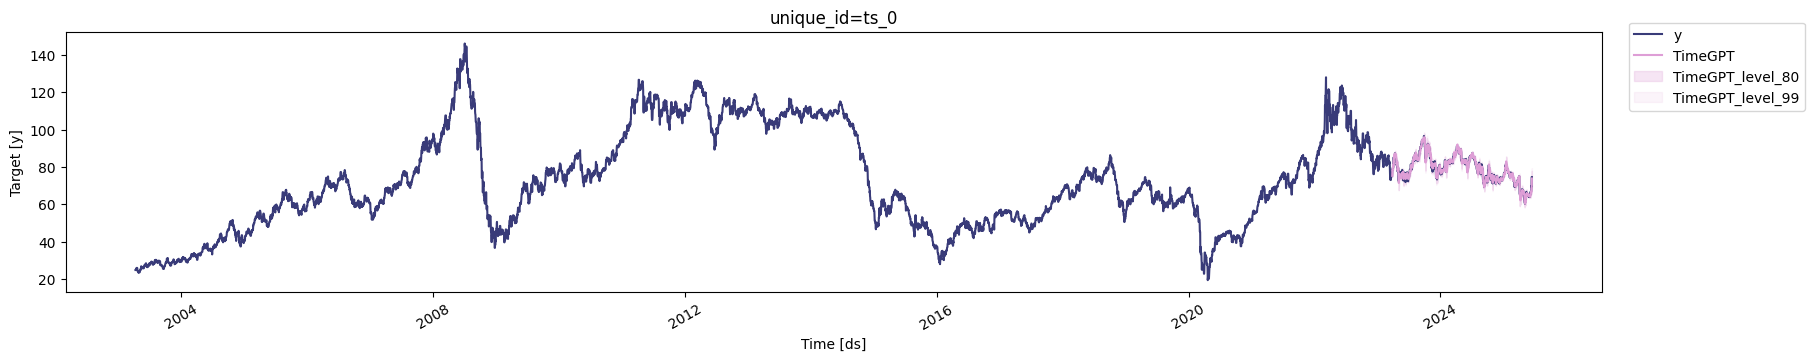

In [51]:
nixtla_client.plot(train_data, test_results, level=CONFIDENCE_LEVELS)

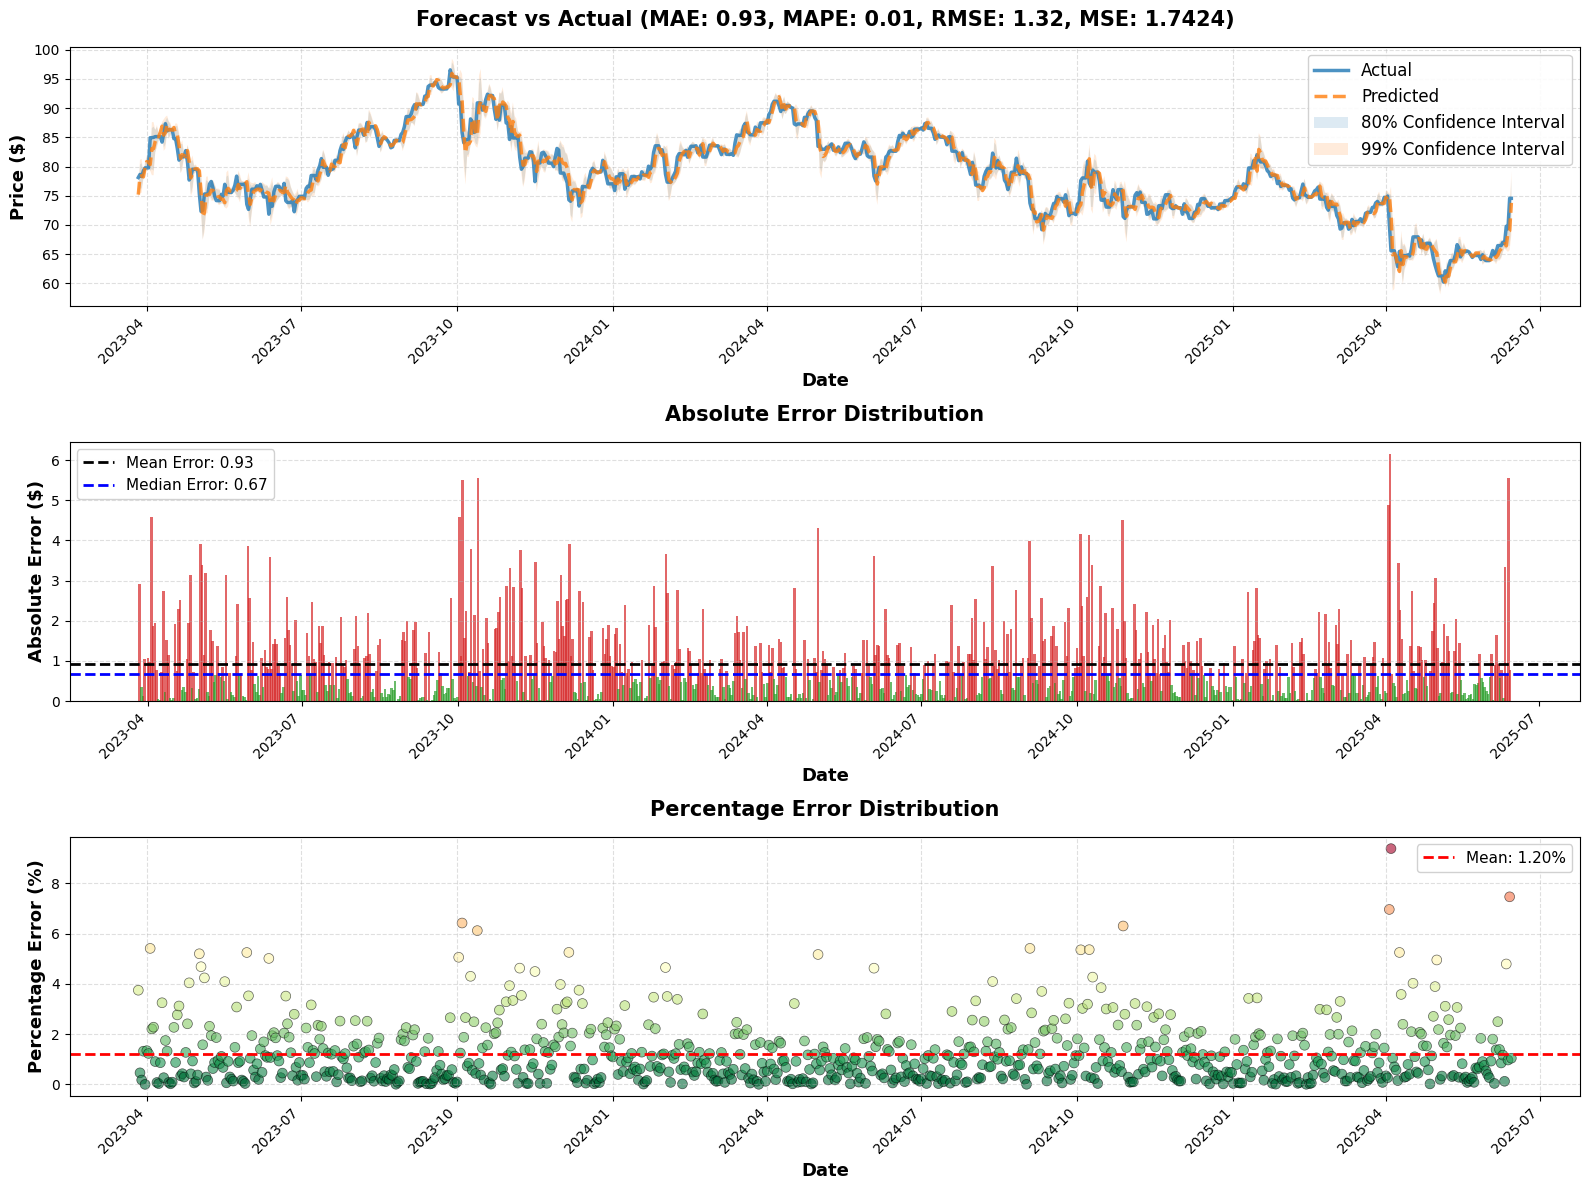

In [52]:
def visualize_forecast_results(
    results_df: pd.DataFrame,
    metrics: Dict[str, float],
    confidence_levels: list[int],
    figsize: Tuple[int, int] = (16, 12),
) -> None:
    fig, axes = plt.subplots(3, 1, figsize=figsize)

    ax_forecast = axes[0]
    ax_forecast.plot(
        results_df["ds"],
        results_df["y"],
        label="Actual",
        color="#1f77b4",
        linewidth=2.5,
        alpha=0.8,
    )
    ax_forecast.plot(
        results_df["ds"],
        results_df["TimeGPT"],
        label="Predicted",
        color="#ff7f0e",
        linewidth=2.5,
        alpha=0.8,
        linestyle="--",
    )

    for level in confidence_levels:
        ax_forecast.fill_between(
            results_df["ds"],
            results_df[f"TimeGPT-lo-{level}"],
            results_df[f"TimeGPT-hi-{level}"],
            alpha=0.15,
            label=f"{level}% Confidence Interval",
        )

    ax_forecast.set_xlabel("Date", fontsize=13, fontweight="bold")
    ax_forecast.set_ylabel("Price ($)", fontsize=13, fontweight="bold")
    ax_forecast.set_title(
        f"Forecast vs Actual (MAE: {metrics['MAE']:.2f}, MAPE: {metrics['MAPE']:.2f}, RMSE: {metrics['RMSE']:.2f}, MSE: {metrics['MSE']:.4f})",
        fontsize=15,
        fontweight="bold",
        pad=15,
    )
    ax_forecast.legend(fontsize=12, loc="best", framealpha=0.9)
    ax_forecast.grid(True, alpha=0.4, linestyle="--")
    ax_forecast.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax_forecast.xaxis.get_majorticklabels(), rotation=45, ha="right")

    ax_abs_error = axes[1]
    absolute_error = np.abs(results_df["y"] - results_df["TimeGPT"])
    median_error = absolute_error.median()
    colors = ["#2ca02c" if err < median_error else "#d62728" for err in absolute_error]
    ax_abs_error.bar(
        results_df["ds"],
        absolute_error,
        color=colors,
        alpha=0.7,
        width=1.5,
    )
    ax_abs_error.axhline(
        absolute_error.mean(),
        color="black",
        linestyle="--",
        linewidth=2,
        label=f"Mean Error: {absolute_error.mean():.2f}",
    )
    ax_abs_error.axhline(
        median_error,
        color="blue",
        linestyle="--",
        linewidth=2,
        label=f"Median Error: {median_error:.2f}",
    )
    ax_abs_error.set_xlabel("Date", fontsize=13, fontweight="bold")
    ax_abs_error.set_ylabel("Absolute Error ($)", fontsize=13, fontweight="bold")
    ax_abs_error.set_title(
        "Absolute Error Distribution", fontsize=15, fontweight="bold", pad=15
    )
    ax_abs_error.legend(fontsize=11, loc="best", framealpha=0.9)
    ax_abs_error.grid(True, alpha=0.4, axis="y", linestyle="--")
    ax_abs_error.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax_abs_error.xaxis.get_majorticklabels(), rotation=45, ha="right")

    ax_pct_error = axes[2]
    percentage_error = 100 * absolute_error / results_df["y"]
    ax_pct_error.scatter(
        results_df["ds"],
        percentage_error,
        c=percentage_error,
        cmap="RdYlGn_r",
        s=50,
        alpha=0.6,
        edgecolors="black",
        linewidth=0.5,
    )
    ax_pct_error.axhline(
        percentage_error.mean(),
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean: {percentage_error.mean():.2f}%",
    )
    ax_pct_error.set_xlabel("Date", fontsize=13, fontweight="bold")
    ax_pct_error.set_ylabel("Percentage Error (%)", fontsize=13, fontweight="bold")
    ax_pct_error.set_title(
        "Percentage Error Distribution", fontsize=15, fontweight="bold", pad=15
    )
    ax_pct_error.legend(fontsize=11, loc="best", framealpha=0.9)
    ax_pct_error.grid(True, alpha=0.4, linestyle="--")
    ax_pct_error.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax_pct_error.xaxis.get_majorticklabels(), rotation=45, ha="right")

    plt.tight_layout()
    plt.show()


visualize_forecast_results(test_results, test_metrics, CONFIDENCE_LEVELS)

In [53]:
def display_summary_statistics(
    results_df: pd.DataFrame, metrics: Dict[str, float], confidence_levels: list[int]
) -> None:
    print("=" * 70)
    print("TEST SET SUMMARY STATISTICS")
    print("=" * 70)
    print(f"Total Predictions: {len(results_df)}")
    print(
        f"Date Range: {results_df['ds'].min().date()} to {results_df['ds'].max().date()}"
    )

    print(f"\nPerformance Metrics:")
    print(f"  MAE:  {metrics['MAE']:.4f} $")
    print(f"  MSE:  {metrics['MSE']:.4f} $²")
    print(f"  RMSE: {metrics['RMSE']:.4f} $")
    print(f"  MAPE: {metrics['MAPE']*100:.2f}%")

    absolute_error = np.abs(results_df["y"] - results_df["TimeGPT"])
    print(f"\nError Distribution:")
    print(f"  Min Error:        {absolute_error.min():.4f} $")
    print(f"  Max Error:        {absolute_error.max():.4f} $")
    print(f"  Mean Error:       {absolute_error.mean():.4f} $")
    print(f"  Median Error:     {absolute_error.median():.4f} $")
    print(f"  Std Dev:          {absolute_error.std():.4f} $")
    print(f"  Error Skewness:   {absolute_error.skew():.4f}")

    print(f"\nPrice Statistics:")
    print(f"  Actual Mean:      {results_df['y'].mean():.2f} $")
    print(f"  Predicted Mean:   {results_df['TimeGPT'].mean():.2f} $")
    print(
        f"  Mean Bias:        {(results_df['TimeGPT'] - results_df['y']).mean():.4f} $"
    )
    print(f"  Actual Min:       {results_df['y'].min():.2f} $")
    print(f"  Actual Max:       {results_df['y'].max():.2f} $")
    print(f"  Price Range:      {results_df['y'].max() - results_df['y'].min():.2f} $")

    print(f"\nConfidence Interval Coverage:")
    for level in confidence_levels:
        within_interval = (
            (results_df["y"] >= results_df[f"TimeGPT-lo-{level}"])
            & (results_df["y"] <= results_df[f"TimeGPT-hi-{level}"])
        ).sum()
        coverage = (within_interval / len(results_df)) * 100
        avg_width = (
            results_df[f"TimeGPT-hi-{level}"] - results_df[f"TimeGPT-lo-{level}"]
        ).mean()
        expected_coverage = level
        coverage_diff = coverage - expected_coverage
        print(
            f"  {level}% Level: {coverage:.1f}% coverage (expected: {expected_coverage}%, diff: {coverage_diff:+.1f}%)"
        )
        print(f"              Average interval width: ${avg_width:.2f}")

    print("=" * 70)


display_summary_statistics(test_results, test_metrics, CONFIDENCE_LEVELS)

TEST SET SUMMARY STATISTICS
Total Predictions: 811
Date Range: 2023-03-27 to 2025-06-14

Performance Metrics:
  MAE:  0.9315 $
  MSE:  1.7424 $²
  RMSE: 1.3200 $
  MAPE: 1.20%

Error Distribution:
  Min Error:        0.0003 $
  Max Error:        6.1485 $
  Mean Error:       0.9315 $
  Median Error:     0.6716 $
  Std Dev:          0.9358 $
  Error Skewness:   1.8659

Price Statistics:
  Actual Mean:      78.81 $
  Predicted Mean:   78.79 $
  Mean Bias:        -0.0180 $
  Actual Min:       60.23 $
  Actual Max:       96.55 $
  Price Range:      36.32 $

Confidence Interval Coverage:
  80% Level: 61.7% coverage (expected: 80%, diff: -18.3%)
              Average interval width: $2.18
  99% Level: 65.8% coverage (expected: 99%, diff: -33.2%)
              Average interval width: $2.65


yukarı, sabit kalıyor, aşağıya üç sınıfla ayır, threshold değeri yüzdelik değişim açısından bak. yüzde 0.5 threshold. yüzde 0.2.
TimesFM(iyi çıkıyor), Log-Llama, Sundial, Moment, TiRex. timesfm loglama iyi çıkıyor, bizim metotlarla olan farkına bakalım.time series foundational models

### YÖN TAHMİNİ
n--> kaç gün geriden bakarak yönü tahmin edeceğimiz

Accuracy: 0.535
Precision: 0.327
Recall: 0.374
F1 Score: 0.349
Confusion Matrix:
[[333 208]
 [169 101]]


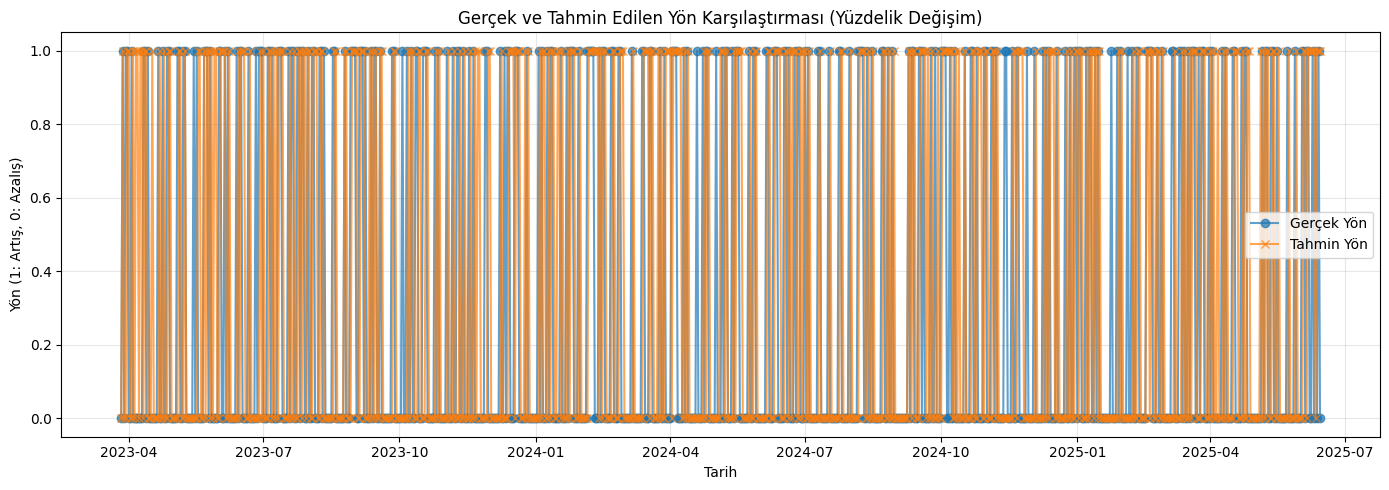

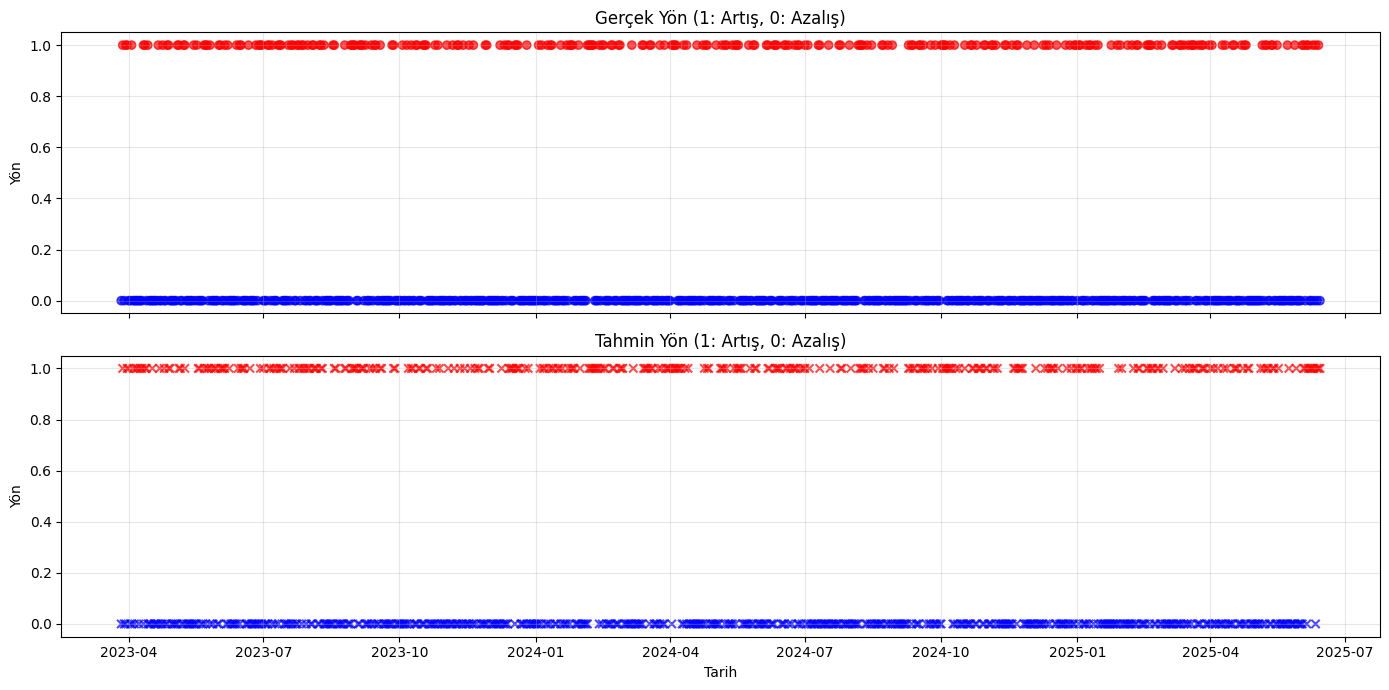

In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

threshold = 0.2  # yüzde threshold, örn. %0.5
n = 1 # kaç gün geriden bakılacak

# Yüzdelik değişim ile yön belirleme
test_results['actual_direction_pct'] = np.where(test_results['y'].pct_change(n) * 100 > threshold, 1, 0)
test_results['predicted_direction_pct'] = np.where(test_results['TimeGPT'].pct_change(n) * 100 > threshold, 1, 0)
direction_df_pct = test_results.dropna(subset=['actual_direction_pct', 'predicted_direction_pct'])

y_true_pct = direction_df_pct['actual_direction_pct']
y_pred_pct = direction_df_pct['predicted_direction_pct']

acc = accuracy_score(y_true_pct, y_pred_pct)
prec = precision_score(y_true_pct, y_pred_pct)
rec = recall_score(y_true_pct, y_pred_pct)
f1 = f1_score(y_true_pct, y_pred_pct)
cm = confusion_matrix(y_true_pct, y_pred_pct)

print(f'Accuracy: {acc:.3f}')
print(f'Precision: {prec:.3f}')
print(f'Recall: {rec:.3f}')
print(f'F1 Score: {f1:.3f}')
print('Confusion Matrix:')
print(cm)

# Görselleştirme
plt.figure(figsize=(14, 5))
plt.plot(direction_df_pct['ds'], direction_df_pct['actual_direction_pct'], label='Gerçek Yön', marker='o', alpha=0.7)
plt.plot(direction_df_pct['ds'], direction_df_pct['predicted_direction_pct'], label='Tahmin Yön', marker='x', alpha=0.7)
plt.xlabel('Tarih')
plt.ylabel('Yön (1: Artış, 0: Azalış)')
plt.title('Gerçek ve Tahmin Edilen Yön Karşılaştırması (Yüzdelik Değişim)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

#ikinci şekil görselleştirme
axes[0].scatter(direction_df_pct['ds'], direction_df_pct['actual_direction_pct'], c=direction_df_pct['actual_direction_pct'], cmap='bwr', marker='o', alpha=0.7)
axes[0].set_title('Gerçek Yön (1: Artış, 0: Azalış)')
axes[0].set_ylabel('Yön')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(direction_df_pct['ds'], direction_df_pct['predicted_direction_pct'], c=direction_df_pct['predicted_direction_pct'], cmap='bwr', marker='x', alpha=0.7)
axes[1].set_title('Tahmin Yön (1: Artış, 0: Azalış)')
axes[1].set_xlabel('Tarih')
axes[1].set_ylabel('Yön')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Smoothing ve Votality adjustment eklenmiş n=1 yapılmış hali
n=1 olduğunda, her günün bir önceki güne göre değişimini (yani en kısa vadeli değişimi) alıyorum. Ancak bu değişimi, ham fiyatlar üzerinden değil, smoothing (ör. 5 günlük ortalama) ile gürültüden arındırılmış değerler üzerinden hesaplıyorum. Ayrıca, bu değişimi o günün volatilitesine (ör. 10 günlük standart sapma) bölerek normalize ediyorum.

Accuracy: 0.745
Precision: 0.677
Recall: 0.662
F1 Score: 0.670
Confusion Matrix:
[[394 100]
 [107 210]]


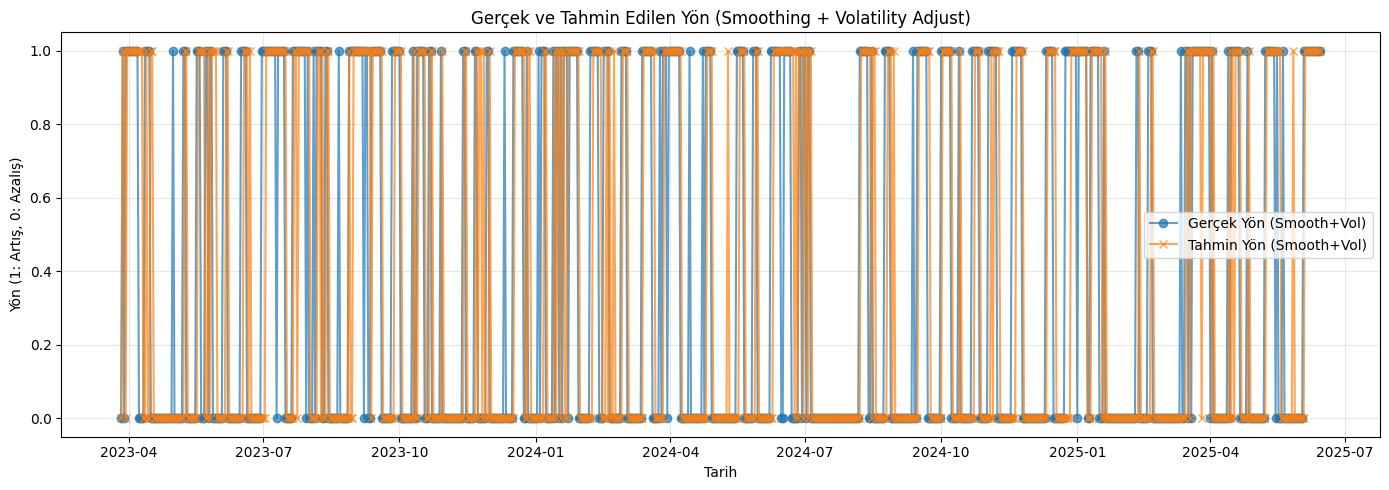

In [55]:
# n=1 için smoothing + volatility adjustment ile yön tahmini
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

# Parametreler
n = 1
threshold = 0.2  # yüzde threshold
smooth_window = 5  # rolling mean penceresi
vol_window = 10   # rolling std penceresi

# Sinyali smooth = rolling mean
# her bir günün değeri, kendisi ve önceki 4 günle birlikte ortalaması alınarak hesaplanıyor, kısa vadeli dalgalanmalar azaltılıyor
smoothed_y = test_results['y'].rolling(window=smooth_window, min_periods=1).mean()
smoothed_pred = test_results['TimeGPT'].rolling(window=smooth_window, min_periods=1).mean()

# Volatility hesapla= standart sapmaya göre yön sinyalini normalize ediyor
vol_y = test_results['y'].rolling(window=vol_window, min_periods=1).std().replace(0, np.nan)
vol_pred = test_results['TimeGPT'].rolling(window=vol_window, min_periods=1).std().replace(0, np.nan)

# Volatility ile normalize edilmiş yüzdelik değişim
adj_pct_y = (smoothed_y.pct_change(n) * 100) / vol_y
adj_pct_pred = (smoothed_pred.pct_change(n) * 100) / vol_pred

# Yön tahmini
actual_direction_smooth = np.where(adj_pct_y > threshold, 1, 0)
predicted_direction_smooth = np.where(adj_pct_pred > threshold, 1, 0)

direction_df_smooth = test_results.copy()
direction_df_smooth['actual_direction_smooth'] = actual_direction_smooth
direction_df_smooth['predicted_direction_smooth'] = predicted_direction_smooth
direction_df_smooth = direction_df_smooth.dropna(subset=['actual_direction_smooth', 'predicted_direction_smooth'])

y_true_smooth = direction_df_smooth['actual_direction_smooth']
y_pred_smooth = direction_df_smooth['predicted_direction_smooth']

acc = accuracy_score(y_true_smooth, y_pred_smooth)
prec = precision_score(y_true_smooth, y_pred_smooth)
rec = recall_score(y_true_smooth, y_pred_smooth)
f1 = f1_score(y_true_smooth, y_pred_smooth)
cm = confusion_matrix(y_true_smooth, y_pred_smooth)

print(f'Accuracy: {acc:.3f}')
print(f'Precision: {prec:.3f}')
print(f'Recall: {rec:.3f}')
print(f'F1 Score: {f1:.3f}')
print('Confusion Matrix:')
print(cm)

# Görselleştirme
plt.figure(figsize=(14, 5))
plt.plot(direction_df_smooth['ds'], direction_df_smooth['actual_direction_smooth'], label='Gerçek Yön (Smooth+Vol)', marker='o', alpha=0.7)
plt.plot(direction_df_smooth['ds'], direction_df_smooth['predicted_direction_smooth'], label='Tahmin Yön (Smooth+Vol)', marker='x', alpha=0.7)
plt.xlabel('Tarih')
plt.ylabel('Yön (1: Artış, 0: Azalış)')
plt.title('Gerçek ve Tahmin Edilen Yön (Smoothing + Volatility Adjust)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3 Sınıflı Yön Tahmini (Yüzdelik Değişim ve Farklı Thresholdlar)
Yönü üç sınıfa ayırıyoruz: Yukarı (+1), Sabit (0), Aşağı (-1). Yüzdelik değişime göre iki farklı threshold ile sonuçları inceliyoruz. -treshold değeri < 0 değeri < + threshold değeri olarak ayarladım bu değerlerden üstte ise 1 altta ise -1.

--- Threshold: %0.5 ---
              precision    recall  f1-score   support

          -1      0.276     0.267     0.271       202
           0      0.533     0.531     0.532       382
           1      0.269     0.278     0.273       227

    accuracy                          0.395       811
   macro avg      0.359     0.359     0.359       811
weighted avg      0.395     0.395     0.395       811

Confusion Matrix:
[[ 54  81  67]
 [ 75 203 104]
 [ 67  97  63]]
--- Threshold: %0.2 ---
              precision    recall  f1-score   support

          -1      0.340     0.402     0.369       251
           0      0.473     0.334     0.392       290
           1      0.327     0.374     0.349       270

    accuracy                          0.369       811
   macro avg      0.380     0.370     0.370       811
weighted avg      0.383     0.369     0.370       811

Confusion Matrix:
[[101  56  94]
 [ 79  97 114]
 [117  52 101]]


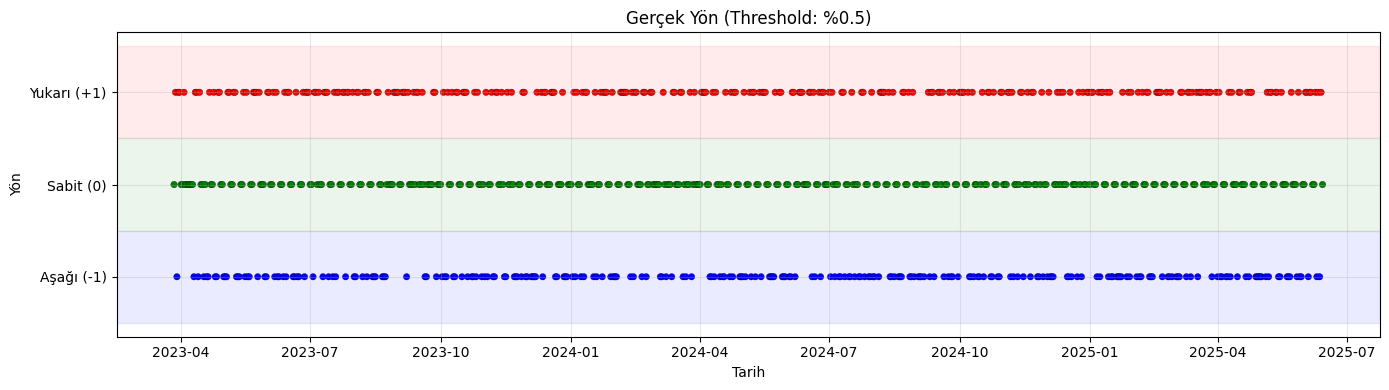

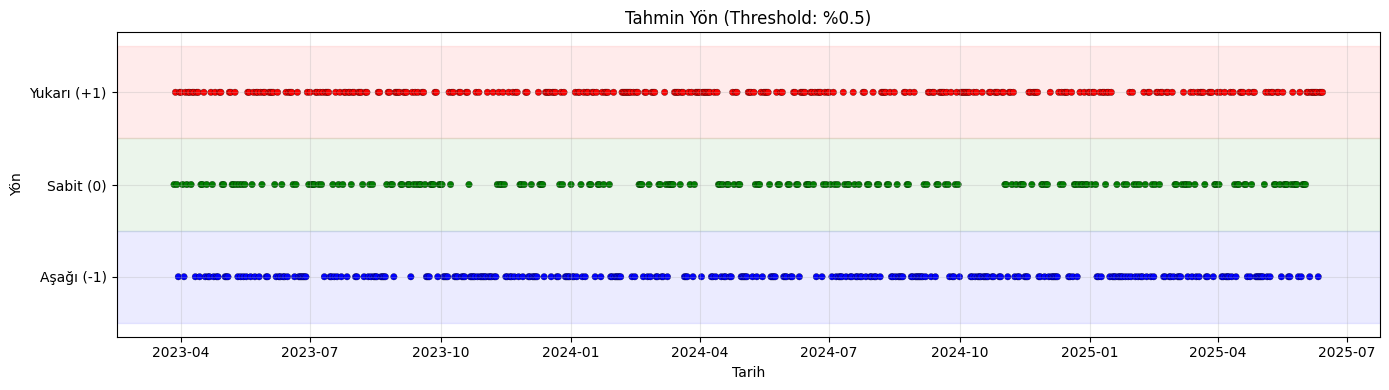

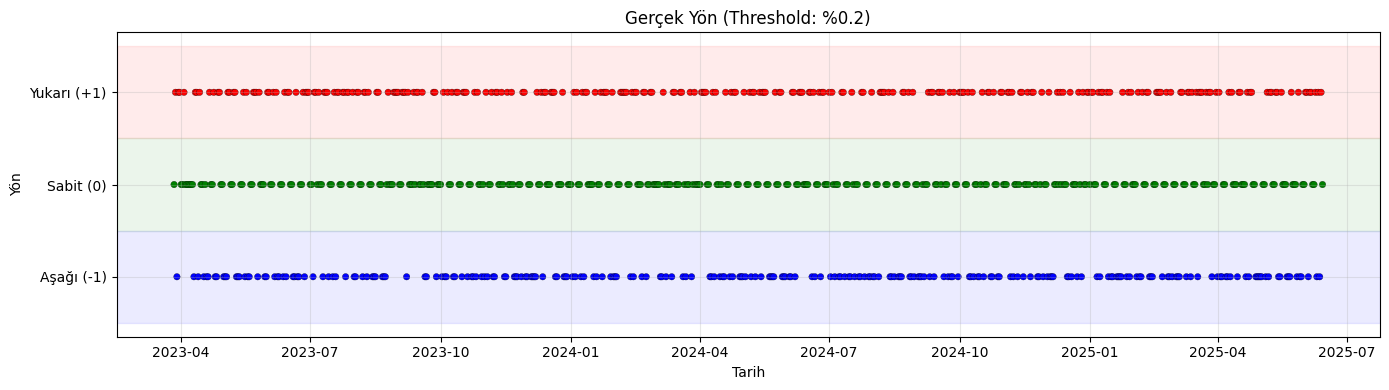

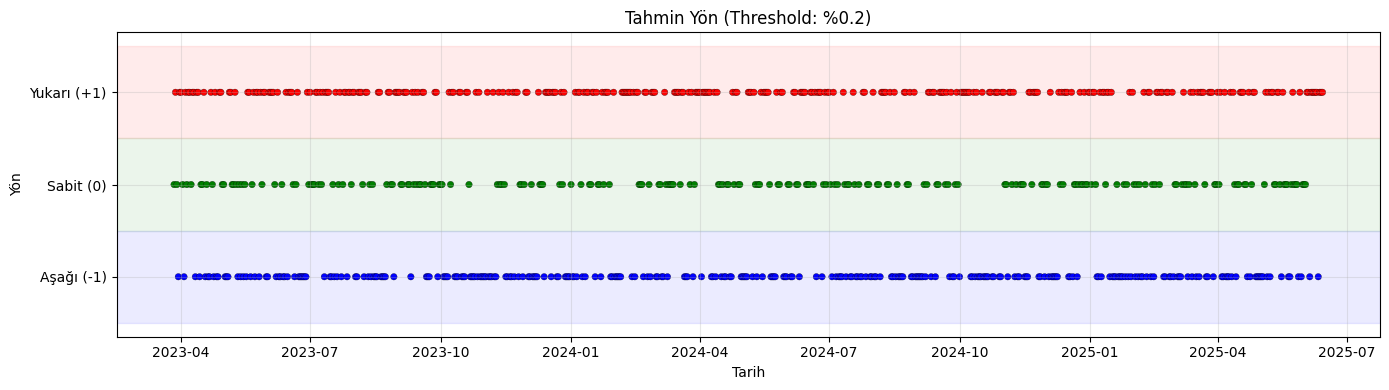

In [56]:
def calc_direction_3class(series, n, pct_threshold):
    pct_change = series.pct_change(n) * 100  # yüzde değişim
    return np.where(pct_change > pct_threshold, 1, np.where(pct_change < -pct_threshold, -1, 0))

n = 1 # horizon
for pct_threshold in [0.5, 0.2]:
    print(f'--- Threshold: %{pct_threshold} ---')
    test_results['actual_direction_3'] = calc_direction_3class(test_results['y'], n, pct_threshold)
    test_results['predicted_direction_3'] = calc_direction_3class(test_results['TimeGPT'], n, pct_threshold)
    direction_df_3 = test_results.dropna(subset=['actual_direction_3', 'predicted_direction_3'])
    y_true_3 = direction_df_3['actual_direction_3']
    y_pred_3 = direction_df_3['predicted_direction_3']


    from sklearn.metrics import classification_report, confusion_matrix

    print(classification_report(y_true_3, y_pred_3, digits=3))
    print('Confusion Matrix:')
    print(confusion_matrix(y_true_3, y_pred_3))


# Görselleştirme
color_map = {1: "red", 0: "green", -1: "blue"}

def get_colors(arr):
    return [color_map[v] for v in arr]

def plot_direction_timeline(df, col, title):
    y_vals = df[col].values
    colors = get_colors(y_vals)

    fig, ax = plt.subplots(figsize=(14, 4))

    # Yatay bantlar
    ax.axhspan(0.5, 1.5, color="red", alpha=0.08)
    ax.axhspan(-0.5, 0.5, color="green", alpha=0.08)
    ax.axhspan(-1.5, -0.5, color="blue", alpha=0.08)

    # Scatter
    ax.scatter(df["ds"], y_vals, c=colors, s=22,
               edgecolor="black", linewidth=0.2)

    ax.set_yticks([1, 0, -1])
    ax.set_yticklabels(["Yukarı (+1)", "Sabit (0)", "Aşağı (-1)"])

    ax.set_title(title)
    ax.set_xlabel("Tarih")
    ax.set_ylabel("Yön")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# --- DÖNGÜ İÇİNDE ÇİZDİRME ---

for pct_threshold in [0.5, 0.2]:

    # Yönleri hesapla
    direction_df_3 = test_results.dropna(
        subset=["actual_direction_3", "predicted_direction_3"]
    )

    # Actual direction plot
    plot_direction_timeline(
        direction_df_3,
        "actual_direction_3",
        f"Gerçek Yön (Threshold: %{pct_threshold})"
    )

    # Predicted direction plot
    plot_direction_timeline(
        direction_df_3,
        "predicted_direction_3",
        f"Tahmin Yön (Threshold: %{pct_threshold})"
    )

### N=1, 3 SINIFLI OLDUĞUNDA
n=1 olduğunda, her günün bir önceki güne göre değişimini (yani en kısa vadeli değişimi) alıyorum. Ancak bu değişimi, ham fiyatlar üzerinden değil, smoothing (ör. 5 günlük ortalama) ile gürültüden arındırılmış değerler üzerinden hesaplıyorum. Ayrıca, bu değişimi o günün volatilitesine (ör. 10 günlük standart sapma) bölerek normalize ediyorum.

--- 3-Class (Smooth+Vol) Threshold: %0.5 ---
              precision    recall  f1-score   support

          -1      0.351     0.354     0.352       113
           0      0.754     0.750     0.752       577
           1      0.407     0.413     0.410       121

    accuracy                          0.645       811
   macro avg      0.504     0.506     0.505       811
weighted avg      0.646     0.645     0.646       811

Confusion Matrix:
[[ 40  72   1]
 [ 72 433  72]
 [  2  69  50]]


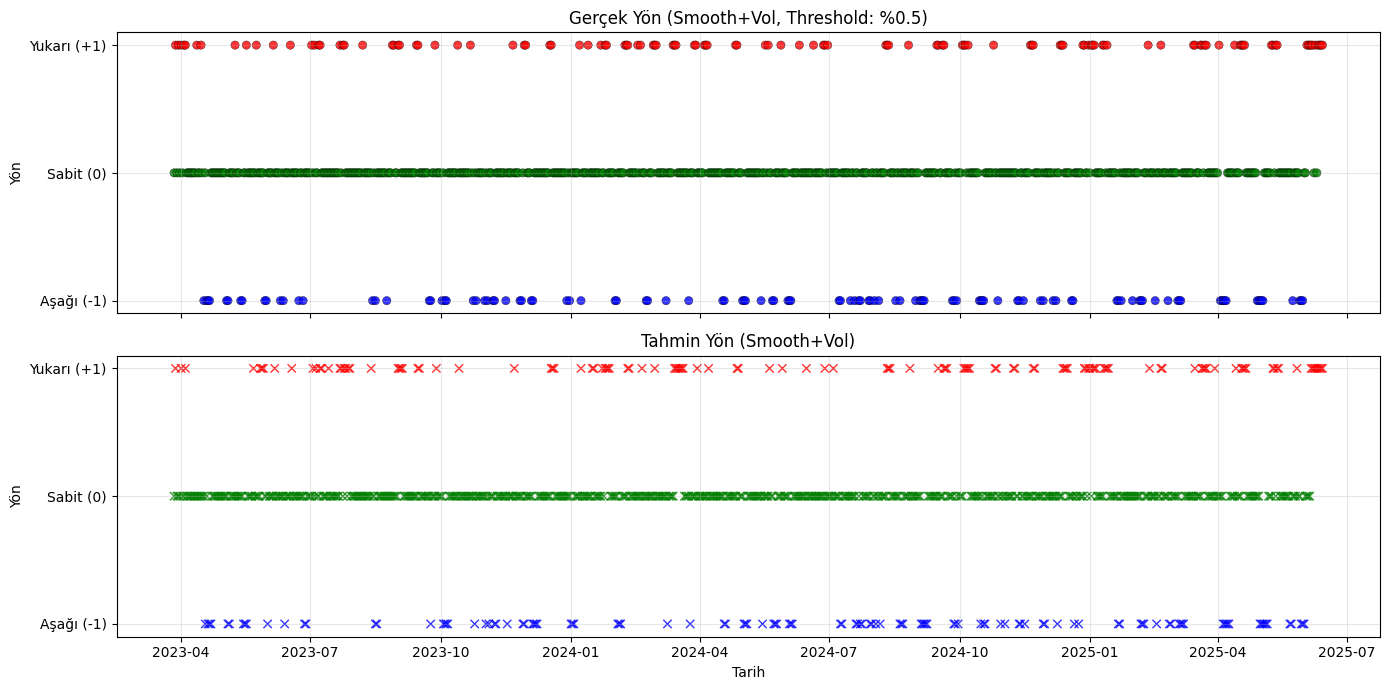

--- 3-Class (Smooth+Vol) Threshold: %0.2 ---
              precision    recall  f1-score   support

          -1      0.686     0.686     0.686       277
           0      0.326     0.336     0.331       217
           1      0.677     0.662     0.670       317

    accuracy                          0.583       811
   macro avg      0.563     0.562     0.562       811
weighted avg      0.586     0.583     0.585       811

Confusion Matrix:
[[190  65  22]
 [ 66  73  78]
 [ 21  86 210]]


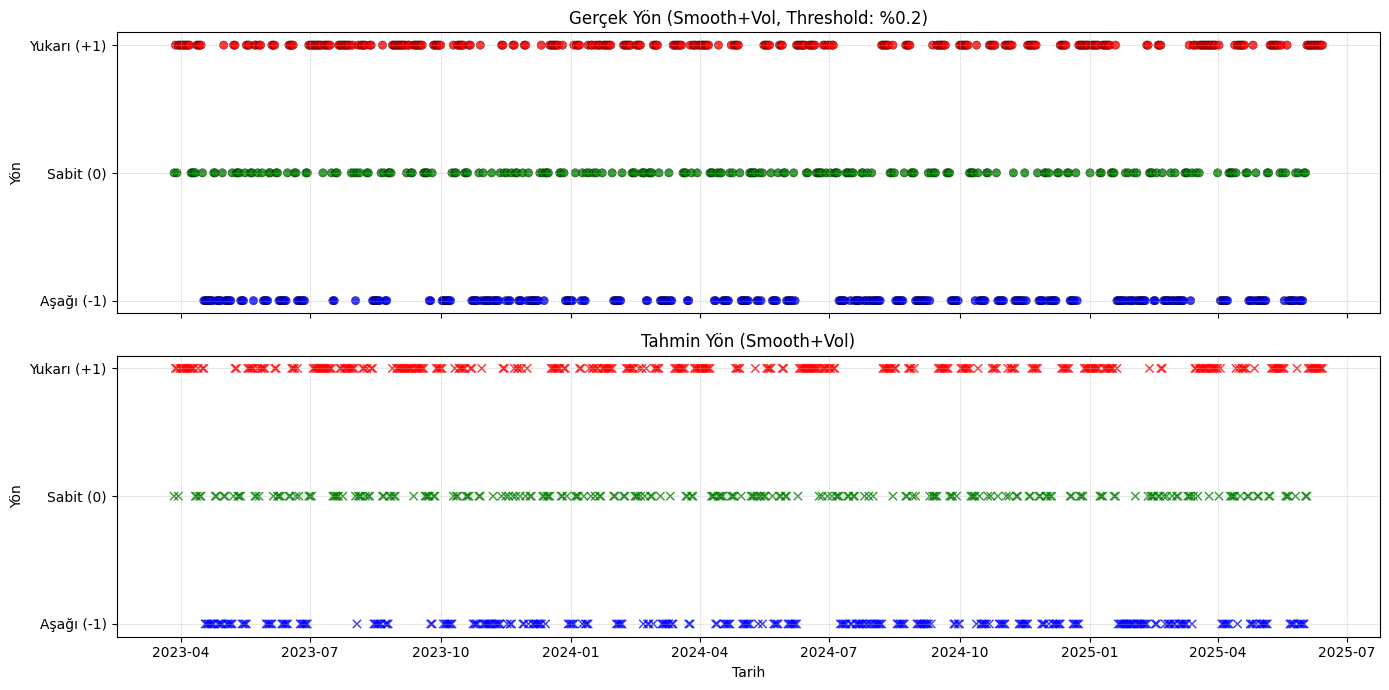

In [57]:
# 3 sınıflı yön tahmini için smoothing + volatility adjustment
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Parametreler
"""
Eğer adj_pct > pct_threshold ise: 1 (yukarı)
Eğer adj_pct < -pct_threshold ise: -1 (aşağı)
Eğer -pct_threshold <= adj_pct <= pct_threshold ise: 0 (sabit)
"""
def direction_3class_smooth_vol(series, n, pct_threshold, smooth_window, vol_window):
    smoothed = series.rolling(window=smooth_window, min_periods=1).mean()
    vol = series.rolling(window=vol_window, min_periods=1).std().replace(0, np.nan)
    adj_pct = (smoothed.pct_change(n) * 100) / vol
    return np.where(adj_pct > pct_threshold, 1, np.where(adj_pct < -pct_threshold, -1, 0)) 

n = 1  # horizon
test_thresholds = [0.5, 0.2]
smooth_window = 5
vol_window = 10

for pct_threshold in test_thresholds:
    print(f'--- 3-Class (Smooth+Vol) Threshold: %{pct_threshold} ---')
    test_results['actual_direction_3_smooth'] = direction_3class_smooth_vol(test_results['y'], n, pct_threshold, smooth_window, vol_window)
    test_results['predicted_direction_3_smooth'] = direction_3class_smooth_vol(test_results['TimeGPT'], n, pct_threshold, smooth_window, vol_window)
    direction_df_3s = test_results.dropna(subset=['actual_direction_3_smooth', 'predicted_direction_3_smooth'])
    y_true_3s = direction_df_3s['actual_direction_3_smooth']
    y_pred_3s = direction_df_3s['predicted_direction_3_smooth']
    print(classification_report(y_true_3s, y_pred_3s, digits=3))
    print('Confusion Matrix:')
    print(confusion_matrix(y_true_3s, y_pred_3s))
    # Görselleştirme

    color_map = {1: "red", 0: "green", -1: "blue"}

    actual_colors = direction_df_3s['actual_direction_3_smooth'].map(color_map)
    pred_colors   = direction_df_3s['predicted_direction_3_smooth'].map(color_map)

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    # --- Actual ---
    axes[0].scatter(
        direction_df_3s['ds'],
        direction_df_3s['actual_direction_3_smooth'],
        c=actual_colors,
        marker='o',
        edgecolor='black',
        linewidth=0.3,
        alpha=0.8
    )
    axes[0].set_title(f'Gerçek Yön (Smooth+Vol, Threshold: %{pct_threshold})')
    axes[0].set_ylabel('Yön')
    axes[0].set_yticks([1, 0, -1])
    axes[0].set_yticklabels(['Yukarı (+1)', 'Sabit (0)', 'Aşağı (-1)'])
    axes[0].grid(True, alpha=0.3)

    # --- Predicted ---
    axes[1].scatter(
        direction_df_3s['ds'],
        direction_df_3s['predicted_direction_3_smooth'],
        c=pred_colors,
        marker='x',
        linewidth=1.0,
        alpha=0.8
    )
    axes[1].set_title('Tahmin Yön (Smooth+Vol)')
    axes[1].set_xlabel('Tarih')
    axes[1].set_ylabel('Yön')
    axes[1].set_yticks([1, 0, -1])
    axes[1].set_yticklabels(['Yukarı (+1)', 'Sabit (0)', 'Aşağı (-1)'])
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### zeroshot timegpt dene, timesfm multivariate dene